# Validation with Convolution Notebook

This notebook validates backgorund model with a non-trivial background; a powerlaw convolved with a representative low loss spectrum.

In [ ]:
import sys
sys.path.append('../Code')
from CLfitter import *
from Validation import *
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import os

## Training and plotting configuration

Set the neural-network, clustering, and output parameters used during validation.

In [ ]:

config = {
    # ── NNTrainer: energy preprocessing ──────────────────────────────────
    "log_energy":               True,
    "standardize_targets":      False,

    # ── NNTrainer.train() ────────────────────────────────────────────────
    "epochs":                   200,
    "lr":                       1e-3,
    "batch_size":               100,
    "patience":                 100,
    "min_delta":                1e-4,
    "progress":                 False,
    "lambda_deriv":             10.0,

    # ── NNTrainer.evaluate_model() ───────────────────────────────────────
    "effective_exponent_window_size": 5,

    # ── Pooler.pool_data() ───────────────────────────────────────────────
    "pool_radius":              2,
    "gaussian_kernel":          True,
    "pool_sigma":               None,   # None uses library default (radius / 2)

    # ── ClusterAnalyzer.cluster_data() ───────────────────────────────────
    "n_clusters":               6,

    # ── BackgroundTrainer.train_MC_replica_consecutive() ─────────────────
    "n_mc_replicas":            1,
    "replica_version":          "covariance",   # "triangular"|"covariance"
    "logging":                  False,

    # ── Job Info ─────────────────────────────────────────────────────────
    'parallelize':        True,
    'n_runs':             10, # Total number of replicas is n_runs * n_mc_replicas

    # ── Output paths ───────────────────────────────────────────────────
    'fitdata_path':       r'tempdata\validation_plural',
    }

#create output directory if it doesn't exist
os.makedirs(config['fitdata_path'], exist_ok=True)

In [7]:
class EELSBackgroundNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 64),
            nn.SiLU(),
            nn.Linear(64, 64),
            nn.SiLU(),
            nn.Linear(64, 1),
        )
    def forward(self, x):
        return self.model(x)

## Generate simulated data

Build the synthetic EELS dataset with plural-scattering convolution and prepare the ground truth for later comparison.

Starting SNR=16 E_edge=100


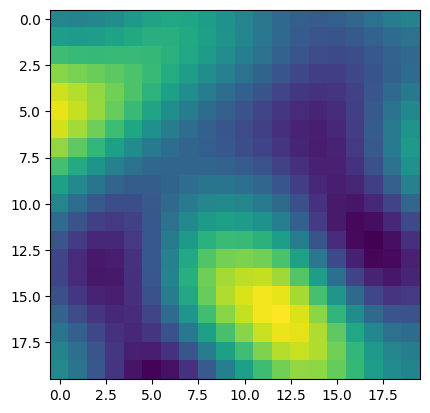

In [ ]:
SNR = 16
pre_edge_region = 100

E_start, E_stop = 300,600
E_edge = E_start+pre_edge_region
low_loss = LowLossEELS(E_0=200e3, beta=10e-3, dispersion=(E_stop - E_start) / 900)

SIG = SpectralImageGenerator(20, 20, 900, E_start, E_stop)

syntheticdata, energy_axis = SIG.generate_realistic_spectral_image(
    low_loss_eels=low_loss,
    apply_plural_scattering=True,
    gaussian_snr=40,
    seed=40,
    scale = 50
    )


syntheticdata = syntheticdata.reshape(900, 400)
ground_truth = SIG.background.reshape(900,400)

## Data preparation and clustering

Convert the synthetic spectral image into the format used by the fitter, then cluster the data for use in background training.

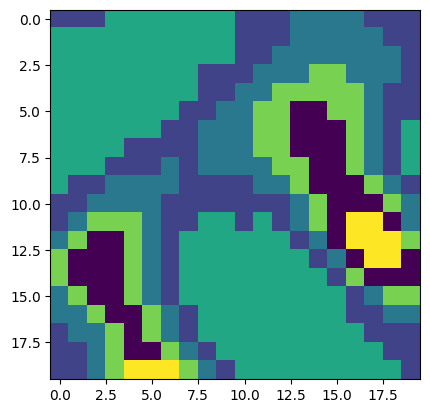

In [9]:
handler = DataHandler()
handler.other_data(syntheticdata, np.arange(20), np.arange(20), energy_axis)
signal =  handler.signal.copy()
i = (E_start-5 ,E_edge ,E_stop+5)

range_mask = (handler.energy_axis > i[0]) & (handler.energy_axis < i[-1])  # Range for clustering shape [n_E_1]

energy_range = handler.energy_axis[range_mask] # shape [n_E_1]
signal_range = signal.copy()[range_mask,:]  # shape [n_E_1, n_y*n_x]
ground_truth_range = ground_truth.copy()[range_mask,:]
pre_edge_mask = (energy_range > i[0]) & (energy_range < i[1])  # Range for pre-edge shape [n_E_2]

clusterer = ClusterAnalyzer(signal_range)
clusterer.cluster_data(config = config, pre_edge_mask=pre_edge_mask,)
clusterer.cholesky_decomp()
plt.imshow(clusterer.clusters.reshape(20,20))  
X_builder = X_Builder(energy_range)
X_builder.prepare_X_mc_data(clusterer.cluster_centers, i[1])
X_builder.prepare_X_eval_data(clusterer.total_integrated_intensity)

## Background training routine

Train the background model with MC replicas for each cluster, then save the replicated predictions for uncertainty analysis.

In [ ]:
def train_background(ii, signal_range, pre_edge_mask, X_builder, clusterer, i):
    background_trainer = BackgroundTrainer(
        signal=signal_range,
        pre_edge_mask=pre_edge_mask,
        X_mc=X_builder.X_mc,
        X_eval=X_builder.X_eval,
        clustered_spectra_mean=clusterer.clusters_mean,
        triangular_matices=clusterer.triangular_matices,
        covariance_matrices=clusterer.clusters_covariance,
        cluster_labels=clusterer.clusters
    )

    background_trainer.train_MC_replica_consecutive(
        edge_onset=i[1],
        model = EELSBackgroundNN(),        
        config = config
    )

    np.savez(f'fitruns3/pred_{ii}.npz', pred = background_trainer.background)
    
    del background_trainer
    # Force garbage collection
    import gc
    gc.collect()

n_jobs = config['n_runs'] if config['parallelize'] else 1

from joblib import Parallel, delayed
Parallel(n_jobs=n_jobs)(
    delayed(train_background)(ii, signal_range, pre_edge_mask, X_builder, clusterer, i)
    for ii in range(0, n_jobs)
)

c:\Users\bartwielen\OneDrive - Delft University of Technology\EELSFitter\CLfitter\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:1105: UserWarning: On Windows, max_workers cannot exceed 61 due to limitations of the operating system.
  warnings.warn(


## Analysis and visualization

Plot the low-loss kernel, compare plural and single scattering spectra, and fit the plural scattering tail using a power-law model.

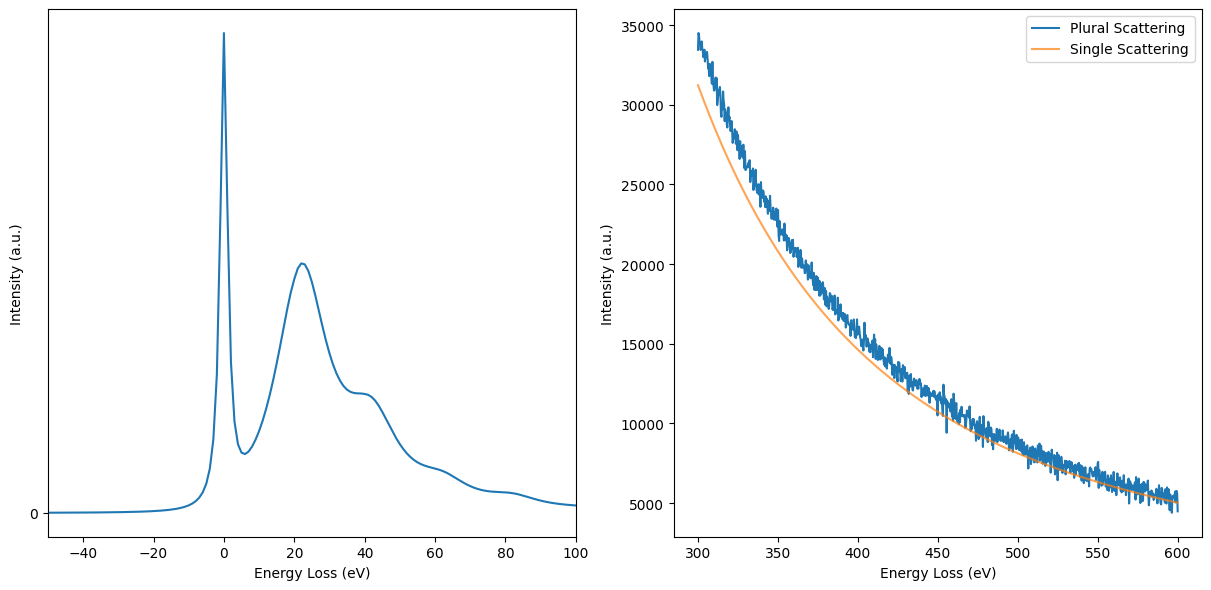

Fitted parameters: A = 1.78e+11, r = 2.71


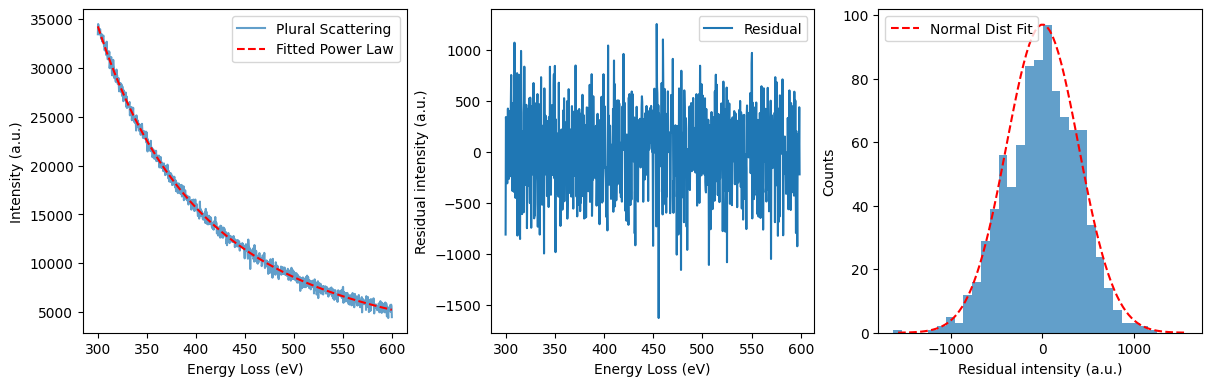

In [7]:
xx, yy = 10, 10

dispersion = SIG.energy_axis[1] - SIG.energy_axis[0]

zlp_idx = np.argmax(SIG.kernel)
low_loss_energy_axis = low_loss.energy_values

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# low-loss kernel for the selected pixel
axes[0].plot(low_loss_energy_axis, SIG.kernel)
axes[0].set_ylabel('Intensity (a.u.)')
axes[0].set_xlabel('Energy Loss (eV)')
axes[0].set_yticks([0])
axes[0].set_xlim(-50, 100)
axes[0].set_box_aspect(1)

# compare plural scattering to the original single-scattering spectrum
plural_scattering_spectrum = SIG.spectral_image[:, xx, yy]
single_scattering_spectrum = SIG.original_spectral_image[152:, xx, yy]

axes[1].plot(SIG.energy_axis, plural_scattering_spectrum, label='Plural Scattering')
axes[1].plot(SIG.energy_axis, single_scattering_spectrum, label='Single Scattering', alpha=0.7)
axes[1].set_xlabel('Energy Loss (eV)')
axes[1].set_ylabel('Intensity (a.u.)')
axes[1].legend()
axes[1].set_box_aspect(1)

plt.show()

# Fit the plural scattering tail with a simple power-law model
from scipy.optimize import curve_fit

def power_law(E, A, r):
    return A * E**(-r)

E_fit = SIG.energy_axis[:]  # Fit over the available energy range
popt, pcov = curve_fit(power_law, E_fit, plural_scattering_spectrum)
A_fit, r_fit = popt
print(f"Fitted parameters: A = {A_fit:.2e}, r = {r_fit:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 6), constrained_layout=True)

# power-law fit versus data
axes[0].plot(E_fit, plural_scattering_spectrum, label='Plural Scattering', alpha=0.7)
axes[0].plot(E_fit, power_law(E_fit, A_fit, r_fit), 'r--', label='Fitted Power Law')
axes[0].set_xlabel('Energy Loss (eV)')
axes[0].set_ylabel('Intensity (a.u.)')
axes[0].legend()
axes[0].set_box_aspect(1)

# residuals between data and fit
residual = plural_scattering_spectrum - power_law(E_fit, A_fit, r_fit)
axes[1].plot(E_fit[:-4], residual[:-4], label='Residual')
axes[1].set_xlabel('Energy Loss (eV)')
axes[1].set_ylabel('Residual intensity (a.u.)')
axes[1].legend()
axes[1].set_box_aspect(1)

# residual distribution compared to a normal curve
axes[2].hist(residual[:-4], bins=30, alpha=0.7)
stdev = np.std(residual[:-4])
mean = np.mean(residual[:-4])

x = np.linspace(mean - 4*stdev, mean + 4*stdev, 100)
normal_dist = (1/(stdev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / stdev)**2)
axes[2].plot(x, normal_dist/max(normal_dist)*max(np.histogram(residual[:-4], bins=30)[0]), 'r--', label='Normal Dist Fit')
axes[2].set_xlabel('Residual intensity (a.u.)')
axes[2].set_ylabel('Counts')
axes[2].legend()
axes[2].set_box_aspect(1)


## Plural scattering visualization and power-law residual analysis

The next block compares plural and single scattering spectra, then fits the plural scattering tail with a power law and inspects the residual distribution.

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bartwielen\AppData\Local\Temp\ipykernel_18436\1697665527.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel('Difference to Theory ($\sigma$)')


(10, 10, 400, 900)


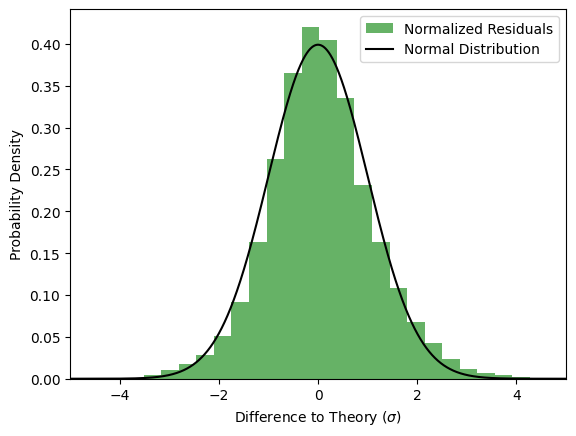

(20, 20, 300) (20, 20, 300)


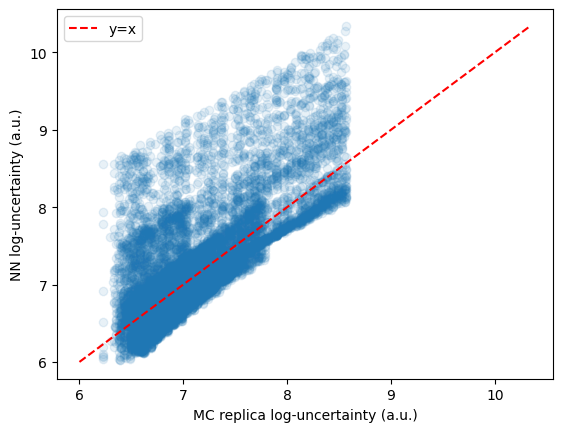

In [ ]:
# Load saved prediction replicas and build the full prediction array
for i in range(10):
    try:
        data1 = np.load(f'fitruns2/pred_{i}.npz')
        pred1 = data1['pred']
        if i == 0:
            predictions = np.zeros((10,*pred1.shape))
        predictions[i] = pred1
    except FileNotFoundError:
        print(f"File fitruns2/pred_{i}.npz not found. Skipping this replica.")
print(predictions.shape)
# reshape across all replicas
predictions = predictions.reshape(10*pred1.shape[0], pred1.shape[1], pred1.shape[2])
predictions_std = np.nanstd(predictions, axis=0).reshape(20, 20, -1)
GT = ground_truth_range.T.reshape(20, 20, 900).copy()

# normalised difference between replica ensemble and the true background
normalized_difference_to_theory = (predictions.reshape(100, 20, 20, 900) - GT[None, :, :, :]) / predictions_std[None, :, :, :]

plt.hist(normalized_difference_to_theory.flatten(), bins=50, density=True, alpha=0.6, color='g', label='Normalized Residuals')
x = np.linspace(-10, 10, 10000)
plt.plot(x, 1/np.sqrt(2*np.pi)*np.exp(-x**2/2), c='black', label='Normal Distribution')
plt.xlabel('Difference to Theory ($\sigma$)')
plt.ylabel('Probability Density')
plt.legend()
plt.xlim(-5, 5)
plt.show()

# compute cluster-level uncertainty from the fitted covariance matrices
centers = clusterer.cluster_centers
mean = clusterer.clusters_mean
cov = clusterer.clusters_covariance
labels = clusterer.clusters.reshape(20, 20)

cluster_std = np.zeros_like(predictions_std[:, :, :300])
for i in range(np.max(labels) + 1):
    mu = mean[:, i]
    sigma2 = np.diag(cov[:, :, i])
    sigma_linear = np.sqrt((np.exp(sigma2) - 1) * np.exp(2 * mu + sigma2))
    cluster_std[labels == i] = sigma_linear

# compare cluster-based uncertainties with MC replica-derived uncertainties
cluster_error_per_point = cluster_std
prediction_error_per_point = predictions_std[:, :, :300]
print(cluster_error_per_point.shape, prediction_error_per_point.shape)

x = cluster_error_per_point.flatten()
y = prediction_error_per_point.flatten()
mask = np.zeros_like(x, dtype=bool)
idx = np.random.choice(len(x), size=int(0.1 * len(x)), replace=False)
mask[idx] = True

straight_line = np.linspace(6, max(np.log(x).max(), np.log(y).max()), 100)
plt.plot(straight_line, straight_line, 'r--', label='y=x')
plt.ylabel('NN log-uncertainty (a.u.)')
plt.xlabel('MC replica log-uncertainty (a.u.)')
plt.scatter(np.log(x).flatten()[mask], np.log(y).flatten()[mask], alpha=0.1)
plt.legend()
plt.show()

In [ ]:
# Notes:
# This final cell is reserved for any follow-up validation checks,
# additional figure exports, or a short summary of the results.
# You can add a final discussion point here once the plots are confirmed.
